In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
df = pd.read_csv(URL)

df["date"] = pd.to_datetime(df["date"])

La colonna location contiene sia paesi reali come Italy e Germany, che aggregati come i continenti (Europe, Asia...), gruppi per reddito (High-income countries...) e il mondo intero (World). Nei record aggregati la colonna continent è NaN. Per questo motivo in ogni analisi ho filtrato sempre per valori specifici di location per evitare di mischiare dati puntuali e aggregati.
Per quanto riguarda total_cases e new_cases hanno logiche diverse. total_cases è cumulativo, cresce nel tempo e rappresenta il totale dei casi dall'inizio della pandemia. new_cases invece rappresenta i nuovi casi registrati in quel giorno o settimana ed è utile per vedere l'andamento delle ondate. Per questo motivo le ho trattate diversamente: per i totali ho usato .max(), per i nuovi casi ho usato i valori diretti.

In [3]:
df.shape
df.head()
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    429435 non-null  object        
 1   continent                                   402910 non-null  object        
 2   location                                    429435 non-null  object        
 3   date                                        429435 non-null  datetime64[ns]
 4   total_cases                                 411804 non-null  float64       
 5   new_cases                                   410159 non-null  float64       
 6   new_cases_smoothed                          408929 non-null  float64       
 7   total_deaths                                411804 non-null  float64       
 8   new_deaths                                  410608 non-null  float64      

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64

In [4]:
for col in df.columns:
    if df[col].dtype == "object":
        print("Colonna:", col)
        print("Valori unici:", df[col].nunique())
        print(df[col].value_counts())
        print("---")

Colonna: iso_code
Valori unici: 255
iso_code
OWID_HIC    3026
OWID_EUN    3024
OWID_UMC    3013
OWID_LMC    2983
OWID_LIC    2724
            ... 
OWID_SCT    1305
OWID_WLS    1198
MAC          795
OWID_CYN     691
ESH            1
Name: count, Length: 255, dtype: int64
---
Colonna: continent
Valori unici: 6
continent
Africa           95419
Europe           91031
Asia             84199
North America    68638
Oceania          40183
South America    23440
Name: count, dtype: int64
---
Colonna: location
Valori unici: 255
location
High-income countries            3026
European Union (27)              3024
Upper-middle-income countries    3013
Lower-middle-income countries    2983
Low-income countries             2724
                                 ... 
Scotland                         1305
Wales                            1198
Macao                             795
Northern Cyprus                   691
Western Sahara                      1
Name: count, Length: 255, dtype: int64
---
Colonn

In [6]:
filtro_reali = df["iso_code"].str.startswith("OWID") == False
df_paesi = df.loc[filtro_reali]

In [7]:
filtro_italia = df["location"] == "Italy"
filtro_2022 = df["date"].dt.year == 2022
filtro_new_cases = df["new_cases"].isna() == False

df_ita_2022 = df.loc[filtro_italia & filtro_2022 & filtro_new_cases]

print("Righe rimaste:", df_ita_2022.shape[0])
df_ita_2022.head()

Righe rimaste: 365


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186002,ITA,Europe,Italy,2022-01-01,5622431.0,0.0,36797.00,136530.0,0.0,140.86,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.3,12.99,8.06,2849.48
186004,ITA,Europe,Italy,2022-01-03,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186005,ITA,Europe,Italy,2022-01-04,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186006,ITA,Europe,Italy,2022-01-05,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


In [8]:
filtro_italia = df["location"] == "Italy"
filtro_2022 = df["date"].dt.year == 2022
filtro_new_cases = df["new_cases"] > 0

df_ita_2022 = df.loc[filtro_italia & filtro_2022 & filtro_new_cases]

print("Righe rimaste:", df_ita_2022.shape[0])
df_ita_2022.head()

Righe rimaste: 52


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.30,12.99,8.06,2849.48
186010,ITA,Europe,Italy,2022-01-09,7281297.0,1014262.0,144894.57,138881.0,1368.0,195.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168831.80,12.89,3.94,2859.74
186017,ITA,Europe,Italy,2022-01-16,8549450.0,1268153.0,181164.71,140856.0,1975.0,282.14,...,27.8,NaN,3.18,83.51,0.89,59037472,170089.10,12.83,8.03,2881.04
186024,ITA,Europe,Italy,2022-01-23,9781191.0,1231741.0,175963.00,143296.0,2440.0,348.57,...,27.8,NaN,3.18,83.51,0.89,59037472,171694.19,12.80,10.40,2908.22
186031,ITA,Europe,Italy,2022-01-30,10821375.0,1040184.0,148597.71,145914.0,2618.0,374.00,...,27.8,NaN,3.18,83.51,0.89,59037472,174151.69,12.84,16.50,2949.85


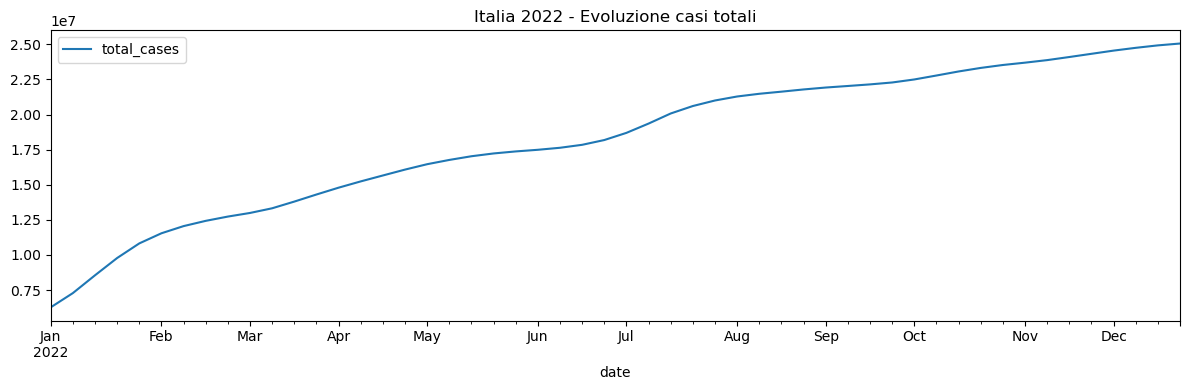

In [9]:
df_ita_2022.plot(x="date", y="total_cases", kind="line",
                 title="Italia 2022 - Evoluzione casi totali",
                 figsize=(12, 4))
plt.tight_layout()
plt.show()

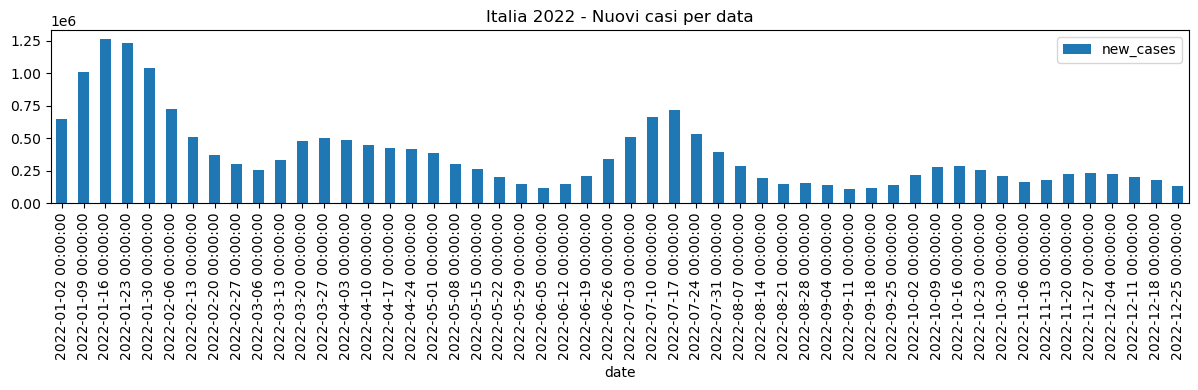

In [10]:
df_ita_2022.plot(x="date", y="new_cases", kind="bar",
                 title="Italia 2022 - Nuovi casi per data",
                 figsize=(12, 4))
plt.tight_layout()
plt.show()

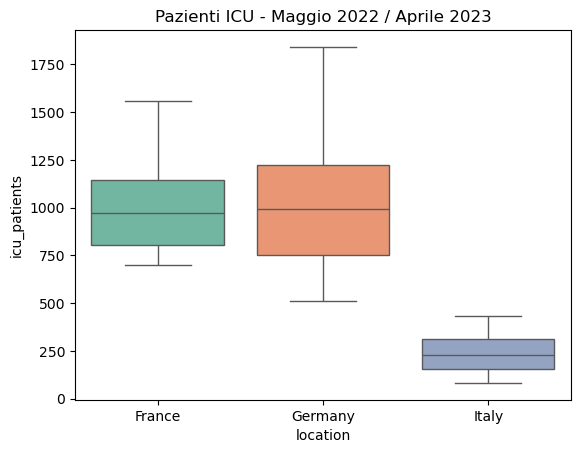

In [12]:
nazioni = ["Italy", "Germany", "France"]

filtro_nazioni = df["location"].isin(nazioni)
filtro_date = (df["date"] >= "2022-05-01") & (df["date"] <= "2023-04-30")
filtro_nulli = df["icu_patients"].isna() == False

df_icu = df.loc[filtro_nazioni & filtro_date & filtro_nulli]

sns.boxplot(data=df_icu, x="location", y="icu_patients",
            hue="location", palette="Set2", legend=False)
plt.title("Pazienti ICU - Maggio 2022 / Aprile 2023")
plt.show()
Francia e Germania hanno mediane simili (circa 1000 pazienti ICU) e una distribuzione ampia, segno di forte variabilità nel periodo. Italia invece ha valori molto più bassi (mediana ~250), probabilmente perché riportava i dati in modo diverso o aveva effettivamente meno posti ICU occupati. La Germania mostra la variabilità maggiore, con valori che vanno da 500 fino a quasi 1900.

In [13]:
nazioni5 = ["Italy", "Germany", "France", "Spain"]

filtro_nazioni5 = df["location"].isin(nazioni5)
filtro_2021 = df["date"].dt.year == 2021

df_hosp = df.loc[filtro_nazioni5 & filtro_2021, ["location", "date", "hosp_patients"]]

# Valori nulli per nazione
df_hosp.isna().sum()

location           0
date               0
hosp_patients    365
dtype: int64

In [17]:
somma = df_hosp.groupby("location")["hosp_patients"].sum().reset_index()
somma.columns = ["Nazione", "Somma hosp_patients"]
somma

,Nazione,Somma hosp_patients
0,France,6008717.0
1,Germany,0.0
2,Italy,4419950.0
3,Spain,2411706.0


In [19]:
df_hosp.groupby("location")["hosp_patients"].apply(lambda x: x.isna().sum())
#La Germania non ha riportato alcun dato di ospedalizzazione (hosp_patients) per tutto il 2021, rendendo impossibile confrontarla con le altre nazioni. In questo caso i valori nulli non possono essere gestiti tramite interpolazione o sostituzione con la media, perché non ci sono dati da cui partire — l'intera colonna è vuota. L'unica soluzione sarebbe trovare i dati da una fonte esterna. Francia, Italia e Spagna invece hanno dati completi: la Francia ha il numero più alto di ospedalizzazioni, seguita da Italia e Spagna.

location
France       0
Germany    365
Italy        0
Spain        0
Name: hosp_patients, dtype: int64

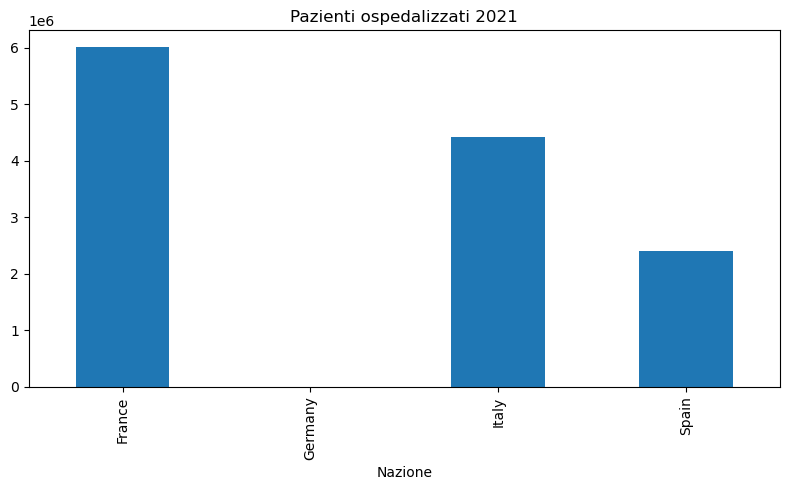

In [20]:
somma.plot(x="Nazione", y="Somma hosp_patients", kind="bar",
           title="Pazienti ospedalizzati 2021",
           figsize=(8, 5), legend=False)
plt.tight_layout()
plt.show()